# Lecture 6: What's under the hood? Minimizers, gradients, and analytic derivatives

**Unit 2, September 15, 2026**

Today we keep the same quantum optics damped oscillation example from Lecture 5 and look under the hood of nonlinear fitting. The point is not to learn a new model. The point is to see how a minimizer moves through parameter space, what the residual vector is, and why derivatives help.

## Research connection: damped Ramsey oscillations in neutral-atom qubits

A real analysis with essentially the same mathematical structure appears in:

**K. Barnes et al., “Assembly and coherent control of a register of nuclear spin qubits,” Nature Communications 13, 2779 (2022).**  
https://doi.org/10.1038/s41467-022-29977-z

In that experiment, the authors use individually trapped neutral atoms as qubits. A Ramsey sequence prepares a superposition, lets it evolve for a time $t_R$, and then measures the final population. If the qubit keeps phase coherence, the measured population oscillates. If the environment slowly randomizes the phase, the oscillation contrast decays.

A simplified version of the fitting model is

$$
y(t_R) = b + a e^{-t_R/T_2^*}\cos(2\pi f t_R + \phi),
$$

or equivalently with a sine instead of a cosine depending on phase convention. This is the same statistical structure as the model we use in this lecture,

$$
P(t) = P_0 + C e^{-t/T_2}\cos(2\pi f t + \phi).
$$

The fitted decay time is interpreted as a coherence time: a longer $T_2$ or $T_2^*$ means the quantum phase survives longer. In the paper, array-averaged Ramsey oscillations remain visible beyond 3 seconds, and the fit gives $T_2^* = 21 \pm 7$ s. That is an extraordinary physics result, but the fitting workflow still depends on the same basic ingredients we are studying here: a nonlinear oscillatory model, weighted residuals, parameter correlations, and uncertainty estimates.

## Learning goals

By the end of this lecture you should be able to:

- write the weighted residual vector for a nonlinear model,
- explain why least-squares fitting minimizes $\chi^2 = \sum_i r_i^2$,
- implement a nonlinear weighted least-squares fit with `scipy.optimize.curve_fit`,
- interpret `popt`, `pcov`, parameter uncertainties, and fit residuals,
- define the Jacobian matrix used by `scipy.optimize.least_squares`,
- implement analytic derivatives for the damped oscillation model.

# Part 1: Imports and shared data

We reuse the same model that we didn't get to at the end of Lecture 5:

$$
P(t;\boldsymbol{\theta}) = P_0 + C e^{-t/T_2}\cos(2\pi f t + \phi),
$$

with parameter vector

$$
\boldsymbol{\theta} = (P_0, C, f, \phi, T_2).
$$

The measured quantity is an excited-state probability estimated from repeated shots. The uncertainty column uses the binomial standard error

$$
\sigma_{P_i} \approx \sqrt{\frac{\hat P_i(1-\hat P_i)}{N_i}}.
$$

This is the same short-window setup from Lecture 5, so $T_2$ is intentionally hard to identify.

In [1]:
%matplotlib inline

from pathlib import Path
import warnings
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, least_squares, minimize
from scipy.stats import chi2

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

rng = np.random.default_rng(20260915)

SCRATCH_DIR = Path("../scratch")
SCRATCH_DIR.mkdir(exist_ok=True)
print(f"NumPy {np.__version__} | pandas {pd.__version__}")

NumPy 2.5.2 | pandas 3.0.5


In [2]:
def damped_oscillation_probability(time_us, offset, contrast, frequency_MHz, phase, coherence_time_us):
    """Damped oscillation model for a measured excited-state probability."""
    envelope = np.exp(-time_us / coherence_time_us)
    angle = 2.0 * np.pi * frequency_MHz * time_us + phase
    return offset + contrast * envelope * np.cos(angle)

parameter_names = ["offset", "contrast", "frequency_MHz", "phase", "coherence_time_us"]
true_parameters = {
    "offset": 0.50,
    "contrast": 0.22,
    "frequency_MHz": 0.82,
    "phase": 0.45,
    "coherence_time_us": 8.0,
}
initial_guess = [0.50, 0.20, 0.80, 0.30, 10.0]
parameter_bounds = ([0.0, 0.0, 0.1, -np.pi, 0.2], [1.0, 0.5, 2.0, np.pi, 50.0])

quantum_data = pd.DataFrame({"time_us": np.linspace(0.0, 1.8, 24)})
quantum_data["true_probability"] = damped_oscillation_probability(
    quantum_data["time_us"],
    *true_parameters.values(),
)
quantum_data["true_probability"] = quantum_data["true_probability"].clip(0.02, 0.98)
quantum_data["shots"] = 180
quantum_data["excited_counts"] = rng.binomial(
    quantum_data["shots"],
    quantum_data["true_probability"],
)
quantum_data["probability"] = quantum_data["excited_counts"] / quantum_data["shots"]
quantum_data["sigma_probability"] = np.sqrt(
    np.maximum(
        quantum_data["probability"] * (1.0 - quantum_data["probability"]) / quantum_data["shots"],
        1.0 / quantum_data["shots"]**2,
    )
)

smooth_quantum_data = pd.DataFrame({
    "time_us": np.linspace(quantum_data["time_us"].min(), quantum_data["time_us"].max(), 400)
})
smooth_quantum_data["true_probability"] = damped_oscillation_probability(
    smooth_quantum_data["time_us"],
    *true_parameters.values(),
).clip(0.02, 0.98)

quantum_data.head()

,time_us,true_probability,shots,excited_counts,probability,sigma_probability
0,0.000000,0.698098,180,128,0.711111,0.033783
1,0.078261,0.643256,180,117,0.650000,0.035551
2,0.156522,0.566708,180,103,0.572222,0.036877
3,0.234783,0.481043,180,85,0.472222,0.037210
4,0.313043,0.400049,180,66,0.366667,0.035918


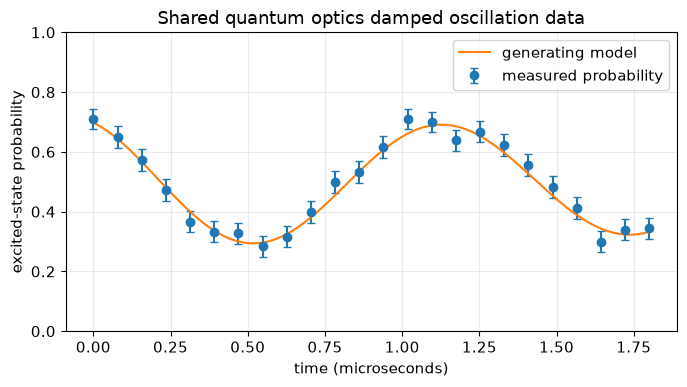

In [3]:
fig, ax = plt.subplots()
ax.errorbar(
    quantum_data["time_us"],
    quantum_data["probability"],
    yerr=quantum_data["sigma_probability"],
    fmt="o",
    capsize=3,
    label="measured probability",
)
ax.plot(
    smooth_quantum_data["time_us"],
    smooth_quantum_data["true_probability"],
    label="generating model",
)
ax.set_xlabel("time (microseconds)")
ax.set_ylabel("excited-state probability")
ax.set_title("Shared quantum optics damped oscillation data")
ax.set_ylim(0.0, 1.0)
ax.legend()
fig.tight_layout()

# Part 2: Weighted least squares

For independent measurements with approximately Gaussian errors, the normalized residual for point $i$ is

$$
r_i(\boldsymbol{\theta}) = \frac{y_i - P(t_i;\boldsymbol{\theta})}{\sigma_i}.
$$

The least-squares objective is

$$
\chi^2(\boldsymbol{\theta}) = \sum_{i=1}^{N} r_i(\boldsymbol{\theta})^2.
$$

Geometrically, $\boldsymbol{r}$ is a vector in data space. Fitting asks for the model parameters that make the length of that vector as small as possible. The model is nonlinear in $f$, $\phi$, and $T_2$, so the objective surface is not a simple parabola everywhere.

In [4]:
def residuals_from_parameters(parameters, data):
    """Return normalized residuals using the pandas DataFrame columns."""
    model_probability = damped_oscillation_probability(data["time_us"], *parameters)
    return (data["probability"] - model_probability) / data["sigma_probability"]


def chi_square_from_parameters(parameters, data):
    residuals = residuals_from_parameters(parameters, data)
    return np.sum(residuals**2)


def fit_with_curve_fit(data, p0=initial_guess, bounds=parameter_bounds, absolute_sigma=True):
    popt, pcov = curve_fit(
        damped_oscillation_probability,
        data["time_us"],
        data["probability"],
        sigma=data["sigma_probability"],
        p0=p0,
        bounds=bounds,
        absolute_sigma=absolute_sigma,
        maxfev=20000,
    )
    return popt, pcov


def covariance_table(popt, pcov):
    sigma = np.sqrt(np.diag(pcov))
    return pd.DataFrame({"parameter": parameter_names, "estimate": popt, "uncertainty": sigma})

In [5]:
trial_a = [0.50, 0.20, 0.80, 0.30, 10.0]
trial_b = [0.48, 0.24, 0.88, -0.10, 4.0]

trial_table = pd.DataFrame(
    {
        "trial": ["A", "B"],
        "chi2": [
            chi_square_from_parameters(trial_a, quantum_data),
            chi_square_from_parameters(trial_b, quantum_data),
        ],
    }
)
trial_table

,trial,chi2
0,A,39.623140
1,B,61.378077


### In-class coding activity 2: residuals and $\chi^2$, 12 minutes

Complete the residual calculation for a new trial parameter set. Then inspect which time points dominate $\chi^2$.

TypeError: unsupported format string passed to ellipsis.__format__

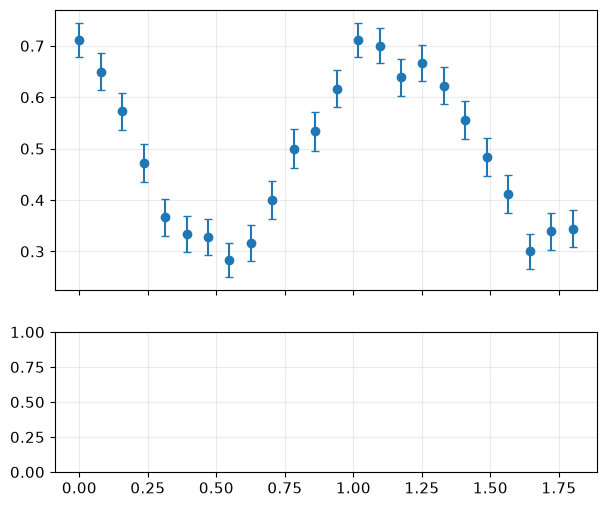

In [7]:
trial_c = [0.52, 0.22, 0.82, 0.45, 8.0]

# TODO: Compute the model prediction, normalized residual, and chi-square.
quantum_data["trial_c_model"] = ...
quantum_data["trial_c_residual"] = ...
trial_c_chi2 = ...  # TODO: sum the squared normalized residuals.

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(7, 6), gridspec_kw={"height_ratios": [2, 1]})
axes[0].errorbar(quantum_data["time_us"], quantum_data["probability"], yerr=quantum_data["sigma_probability"], fmt="o", capsize=3)
axes[0].plot(quantum_data["time_us"], quantum_data["trial_c_model"], label=f"trial C, chi2={trial_c_chi2:.1f}")
axes[0].set_ylabel("probability")
axes[0].set_ylim(0.0, 1.0)
axes[0].legend()

axes[1].axhline(0.0, color="0.5", lw=1)
axes[1].errorbar(quantum_data["time_us"], quantum_data["trial_c_residual"], yerr=np.ones(len(quantum_data)), fmt="o", capsize=3)
axes[1].set_xlabel("time (microseconds)")
axes[1].set_ylabel("norm. residual")
fig.tight_layout()

# Part 3: `curve_fit` as the high-level fitting interface

Before we build the residual vector and Jacobian ourselves, we should use the tool most scientists reach for first: `scipy.optimize.curve_fit`.

`curve_fit` expects a model function whose first argument is the independent variable and whose remaining arguments are the fitted parameters:

```python
def model(x, parameter_1, parameter_2, ...):
    return prediction
```

For our model ```damped_oscillation_probability()```,

$$
P(t;\boldsymbol{\theta}) = P_0 + C e^{-t/T_2}\cos(2\pi f t + \phi),
$$

`curve_fit` adjusts $\boldsymbol{\theta}=(P_0,C,f,\phi,T_2)$ to describe the measured probability data.

When we pass `sigma=quantum_data["sigma_probability"]`, the fit is based on the weighted residuals

$$
r_i = \frac{y_i-P(t_i;\boldsymbol{\theta})}{\sigma_i},
$$

and therefore minimizes

$$
\chi^2(\boldsymbol{\theta}) = \sum_i r_i^2.
$$

The most important outputs are:

- `popt`: the best-fit parameter values,
- `pcov`: the estimated parameter covariance matrix,
- `np.sqrt(np.diag(pcov))`: the approximate one-standard-deviation parameter uncertainties.

Use `absolute_sigma=True` when the `sigma` values are intended to be absolute measurement uncertainties. Then `pcov` is scaled using those uncertainties rather than rescaled to force the reduced $\chi^2$ toward 1.

This is the right first interface for many fitting problems. In Part 4 we will move down one level to `least_squares`, where the residual vector and derivative matrix are explicit.

### In-class coding activity 3: implement the `curve_fit` workflow, 12 minutes

Complete the fit below. Your goal is not only to get best-fit parameters, but to make the standard post-fit diagnostic products: a parameter table, a fit-quality table, and a residual plot.

In [8]:
curve_fit_initial_guess = initial_guess
curve_fit_bounds = parameter_bounds

# TODO: Call curve_fit with the model function, DataFrame columns, uncertainties, initial guess, and bounds.
curve_fit_popt, curve_fit_pcov = curve_fit(
    ...,
    quantum_data["time_us"],
    quantum_data["probability"],
    sigma=quantum_data["sigma_probability"],
    p0=...,  # TODO: pass the initial parameter guesses.
    bounds=...,  # TODO: pass the lower and upper parameter bounds.
    absolute_sigma=True,
    maxfev=20000,
)

curve_fit_parameter_table = pd.DataFrame({
    "parameter": parameter_names,
    "estimate": curve_fit_popt,
    # TODO: Extract one-standard-deviation uncertainties from the covariance matrix.
    "uncertainty": ...,
    "true_value": [true_parameters[name] for name in parameter_names],
})
curve_fit_parameter_table["pull_from_truth"] = (
    curve_fit_parameter_table["estimate"] - curve_fit_parameter_table["true_value"]
) / curve_fit_parameter_table["uncertainty"]

# TODO: Evaluate the fitted model and normalized residuals using DataFrame columns.
quantum_data["curve_fit_probability"] = ...
quantum_data["curve_fit_normalized_residual"] = ...

# TODO: Compute chi-square, degrees of freedom, and reduced chi-square.
curve_fit_chi2 = ...
curve_fit_ndf = ...
curve_fit_reduced_chi2 = ...  # TODO: divide chi-square by the number of degrees of freedom.

curve_fit_quality = pd.DataFrame([
    {
        "method": "curve_fit",
        "chi2": curve_fit_chi2,
        "ndf": curve_fit_ndf,
        "reduced_chi2": curve_fit_reduced_chi2,
    }
])

smooth_quantum_data["curve_fit_probability"] = damped_oscillation_probability(
    smooth_quantum_data["time_us"],
    *curve_fit_popt,
)

display(curve_fit_parameter_table)
display(curve_fit_quality)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(7, 6), gridspec_kw={"height_ratios": [2, 1]})
axes[0].errorbar(
    quantum_data["time_us"],
    quantum_data["probability"],
    yerr=quantum_data["sigma_probability"],
    fmt="o",
    capsize=3,
    label="data",
)
axes[0].plot(smooth_quantum_data["time_us"], smooth_quantum_data["curve_fit_probability"], label="curve_fit result")
axes[0].set_ylabel("probability")
axes[0].set_ylim(0.0, 1.0)
axes[0].legend()

axes[1].axhline(0.0, color="0.5", lw=1)
axes[1].errorbar(
    quantum_data["time_us"],
    quantum_data["curve_fit_normalized_residual"],
    yerr=np.ones(len(quantum_data)),
    fmt="o",
    capsize=3,
)
axes[1].set_xlabel("time (microseconds)")
axes[1].set_ylabel("norm. residual")
fig.tight_layout()

TypeError: 'ellipsis' object is not iterable

# Part 4: How residual derivatives enter the fit

The previous section used `curve_fit`, which is the high-level interface most scientists start with. Now we call `scipy.optimize.least_squares` directly so the residual vector, the Jacobian, and the fitter mechanics are visible.

With the default linear loss, `least_squares` minimizes

$$
F(\boldsymbol{\theta}) = \frac{1}{2}\sum_{i=1}^{N} r_i(\boldsymbol{\theta})^2
= \frac{1}{2}\|\boldsymbol{r}(\boldsymbol{\theta})\|^2.
$$

At each iteration, the optimizer makes a local linear approximation to the residual vector:

$$
\boldsymbol{r}(\boldsymbol{\theta}+\boldsymbol{\Delta})
\approx
\boldsymbol{r}(\boldsymbol{\theta}) + J(\boldsymbol{\theta})\boldsymbol{\Delta},
$$

where the Jacobian matrix is

$$
J_{ij}=\frac{\partial r_i}{\partial \theta_j}.
$$

The trial step $\boldsymbol{\Delta}$ is chosen to reduce the approximate objective

$$
\frac{1}{2}\left\|\boldsymbol{r}+J\boldsymbol{\Delta}\right\|^2.
$$

Ignoring bounds and trust-region details for a moment, this leads to the Gauss-Newton normal equations

$$
J^T J\boldsymbol{\Delta} = -J^T\boldsymbol{r}.
$$

This equation is the main reason the residual derivatives matter. The matrix $J^TJ$ tells the optimizer about the local curvature of the objective surface and about parameter directions that are strongly or weakly constrained.

## What happens by default?

If you do not provide a Jacobian, SciPy estimates it with finite differences. For example, a forward-difference estimate for parameter $\theta_j$ is

$$
J_{ij} \approx \frac{r_i(\boldsymbol{\theta}+h\hat e_j)-r_i(\boldsymbol{\theta})}{h}.
$$

For a five-parameter model, that means several extra residual-vector evaluations every time the optimizer wants a Jacobian. This is usually fine for small examples, but it can become expensive when each model evaluation is slow, and it can be less accurate if the finite-difference step size is poorly matched to the problem.

## Analytic Jacobian for the damped oscillation

For weighted residuals,

$$
r_i = \frac{y_i-P(t_i;\boldsymbol{\theta})}{\sigma_i},
$$

so

$$
J_{ij} = -\frac{1}{\sigma_i}\frac{\partial P(t_i;\boldsymbol{\theta})}{\partial \theta_j}.
$$

For the damped oscillation, define

$$
E_i=e^{-t_i/T_2}, \qquad \Theta_i=2\pi f t_i+\phi.
$$

Then

$$
\begin{aligned}
\frac{\partial P_i}{\partial P_0} &= 1, \\
\frac{\partial P_i}{\partial C} &= E_i\cos\Theta_i, \\
\frac{\partial P_i}{\partial f} &= -C E_i\sin\Theta_i(2\pi t_i), \\
\frac{\partial P_i}{\partial \phi} &= -C E_i\sin\Theta_i, \\
\frac{\partial P_i}{\partial T_2} &= C\cos\Theta_i E_i\frac{t_i}{T_2^2}.
\end{aligned}
$$

The next cell compares SciPy's default finite-difference Jacobian with a supplied analytic Jacobian. The two fits should land at the same minimum, but the analytic Jacobian should require many fewer residual evaluations.

In [9]:
def residual_vector(parameters):
    return residuals_from_parameters(parameters, quantum_data)


def analytic_residual_jacobian(parameters, data):
    """Analytic Jacobian of the normalized residual vector."""
    # Unpack the parameter vector in the same order used by parameter_names.
    offset, contrast, frequency, phase, coherence_time = parameters

    # Keep the calculation tied to the DataFrame columns used in the fit.
    time = data["time_us"]
    sigma = data["sigma_probability"]

    # Reuse the two repeated pieces of the damped oscillation model:
    # envelope = exp(-t/T2), angle = 2*pi*f*t + phi.
    envelope = np.exp(-time / coherence_time)
    angle = 2.0 * np.pi * frequency * time + phase

    # First compute derivatives of the model P(t; theta) with respect to
    # each parameter. Each array below has one entry for each measured time.
    d_model_d_offset = np.ones(len(data))
    d_model_d_contrast = envelope * np.cos(angle)
    d_model_d_frequency = -contrast * envelope * np.sin(angle) * (2.0 * np.pi * time)
    d_model_d_phase = -contrast * envelope * np.sin(angle)

    # d/dT2 exp(-t/T2) = exp(-t/T2) * t / T2^2, so this derivative is positive
    # where cos(angle) is positive and negative where cos(angle) is negative.
    d_model_d_coherence_time = contrast * np.cos(angle) * envelope * time / coherence_time**2

    # Columns correspond to parameters; rows correspond to data points.
    model_jacobian = np.column_stack([
        d_model_d_offset,
        d_model_d_contrast,
        d_model_d_frequency,
        d_model_d_phase,
        d_model_d_coherence_time,
    ])

    # least_squares needs derivatives of residuals, not derivatives of the model.
    # Since residual = (data - model) / sigma, J_residual = -J_model / sigma.
    return -model_jacobian / sigma.to_numpy()[:, None]


def run_counted_least_squares(jacobian_mode):
    """Run one fit while counting residual and analytic-Jacobian calls."""
    residual_counter = {"calls": 0}
    jacobian_counter = {"calls": 0}

    def counted_residual(parameters):
        residual_counter["calls"] += 1
        return residuals_from_parameters(parameters, quantum_data)

    def counted_analytic_jacobian(parameters):
        jacobian_counter["calls"] += 1
        return analytic_residual_jacobian(parameters, quantum_data)

    start_time = perf_counter()
    if jacobian_mode == "analytic":
        result = least_squares(
            counted_residual,
            x0=initial_guess,
            jac=counted_analytic_jacobian,
            bounds=parameter_bounds,
            max_nfev=20000,
        )
        jacobian_label = "analytic Jacobian supplied"
    else:
        result = least_squares(
            counted_residual,
            x0=initial_guess,
            jac="2-point",
            bounds=parameter_bounds,
            max_nfev=20000,
        )
        jacobian_label = "default finite differences"

    elapsed_ms = 1000.0 * (perf_counter() - start_time)
    metadata = {
        "jacobian": jacobian_label,
        "residual_calls": residual_counter["calls"],
        "analytic_jacobian_calls": jacobian_counter["calls"],
        "reported_nfev": result.nfev,
        "reported_njev": result.njev,
        "elapsed_ms": elapsed_ms,
        "chi2": np.sum(result.fun**2),
    }
    return result, metadata


numerical_result, numerical_metadata = run_counted_least_squares("2-point")
analytic_reference_result, analytic_metadata = run_counted_least_squares("analytic")

benchmark_rows = []
for repeat in range(20):
    for jacobian_mode in ["2-point", "analytic"]:
        _, metadata = run_counted_least_squares(jacobian_mode)
        metadata["repeat"] = repeat
        benchmark_rows.append(metadata)

benchmark_data = pd.DataFrame(benchmark_rows)
optimization_comparison = (
    benchmark_data
    .groupby("jacobian", as_index=False)
    .agg(
        residual_calls=("residual_calls", "mean"),
        analytic_jacobian_calls=("analytic_jacobian_calls", "mean"),
        reported_nfev=("reported_nfev", "mean"),
        reported_njev=("reported_njev", "mean"),
        median_elapsed_ms=("elapsed_ms", "median"),
        chi2=("chi2", "mean"),
    )
)
jacobian_order = ["default finite differences", "analytic Jacobian supplied"]
optimization_comparison["jacobian"] = pd.Categorical(
    optimization_comparison["jacobian"],
    categories=jacobian_order,
    ordered=True,
)
optimization_comparison = optimization_comparison.sort_values("jacobian").reset_index(drop=True)
optimization_comparison["jacobian"] = optimization_comparison["jacobian"].astype(str)
optimization_comparison[["residual_calls", "analytic_jacobian_calls", "reported_nfev", "reported_njev", "median_elapsed_ms", "chi2"]] = (
    optimization_comparison[["residual_calls", "analytic_jacobian_calls", "reported_nfev", "reported_njev", "median_elapsed_ms", "chi2"]]
    .round(4)
)

parameter_comparison = pd.DataFrame({
    "parameter": parameter_names,
    "default_finite_difference_fit": numerical_result.x,
    "analytic_jacobian_fit": analytic_reference_result.x,
})
parameter_comparison["difference"] = parameter_comparison["analytic_jacobian_fit"] - parameter_comparison["default_finite_difference_fit"]

print(optimization_comparison.to_string(index=False))
parameter_comparison

                  jacobian  residual_calls  analytic_jacobian_calls  reported_nfev  reported_njev  median_elapsed_ms   chi2
default finite differences            36.0                      0.0            6.0            6.0             7.2649 9.7516
analytic Jacobian supplied             6.0                      6.0            6.0            6.0             3.3905 9.7516


,parameter,default_finite_difference_fit,analytic_jacobian_fit,difference
0,offset,0.509204,0.509204,2.215095e-11
1,contrast,0.233197,0.233197,-6.669863e-10
2,frequency_MHz,0.809608,0.809608,3.159917e-10
3,phase,0.540306,0.540306,-1.468818e-09
4,coherence_time_us,6.603596,6.603596,1.417339e-07


The reported `nfev` and `njev` columns can make the two approaches look more similar than they really are. The direct `residual_calls` counter is the cleaner diagnostic here: the finite-difference calculation has to call the residual function repeatedly to estimate the derivative columns, while the analytic-Jacobian fit evaluates the residual once and the Jacobian once per iteration.

### In-class coding activity 4: build the analytic Jacobian yourself, 6 minutes

The previous cell supplied the analytic Jacobian so we could compare optimization behavior. Now complete a stripped-down version yourself. The goal is to connect each column of the matrix to one derivative in the equations above.

In [ ]:
def residual_jacobian(parameters):
    offset, contrast, frequency, phase, coherence_time = parameters
    time = quantum_data["time_us"]
    sigma = quantum_data["sigma_probability"]
    envelope = np.exp(-time / coherence_time)
    angle = 2.0 * np.pi * frequency * time + phase

    d_model_d_offset = np.ones(len(quantum_data))
    d_model_d_contrast = envelope * np.cos(angle)
    # TODO: Fill in the frequency and phase derivatives from the equations above.
    d_model_d_frequency = ...
    d_model_d_phase = ...
    d_model_d_coherence_time = contrast * np.cos(angle) * envelope * time / coherence_time**2

    model_jacobian = np.column_stack([
        d_model_d_offset,
        d_model_d_contrast,
        d_model_d_frequency,
        d_model_d_phase,
        d_model_d_coherence_time,
    ])
    return -model_jacobian / sigma.to_numpy()[:, None]

analytic_result = least_squares(
    residual_vector,
    x0=initial_guess,
    jac=residual_jacobian,
    bounds=parameter_bounds,
    max_nfev=20000,
)

comparison = pd.DataFrame({
    "parameter": parameter_names,
    "default_finite_difference_fit": numerical_result.x,
    "student_analytic_jacobian_fit": analytic_result.x,
    "provided_analytic_jacobian_fit": analytic_reference_result.x,
})
comparison["student_minus_default"] = comparison["student_analytic_jacobian_fit"] - comparison["default_finite_difference_fit"]
comparison["student_minus_provided"] = comparison["student_analytic_jacobian_fit"] - comparison["provided_analytic_jacobian_fit"]
comparison

In [ ]:
fit_quantum_data = quantum_data.copy()
fit_smooth_data = smooth_quantum_data.copy()
fit_quantum_data["fit_probability"] = damped_oscillation_probability(fit_quantum_data["time_us"], *numerical_result.x)
fit_quantum_data["normalized_residual"] = (fit_quantum_data["probability"] - fit_quantum_data["fit_probability"]) / fit_quantum_data["sigma_probability"]
fit_smooth_data["fit_probability"] = damped_oscillation_probability(fit_smooth_data["time_us"], *numerical_result.x)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(7, 6), gridspec_kw={"height_ratios": [2, 1]})
axes[0].errorbar(fit_quantum_data["time_us"], fit_quantum_data["probability"], yerr=fit_quantum_data["sigma_probability"], fmt="o", capsize=3, label="data")
axes[0].plot(fit_smooth_data["time_us"], fit_smooth_data["fit_probability"], label="least_squares fit")
axes[0].set_ylabel("probability")
axes[0].set_ylim(0.0, 1.0)
axes[0].legend()

axes[1].axhline(0.0, color="0.5", lw=1)
axes[1].errorbar(fit_quantum_data["time_us"], fit_quantum_data["normalized_residual"], yerr=np.ones(len(fit_quantum_data)), fmt="o", capsize=3)
axes[1].set_xlabel("time (microseconds)")
axes[1].set_ylabel("norm. residual")
fig.tight_layout()

# Part 5: Alternative minimizers and what they are optimizing

At this point we have seen three levels of the same fitting problem:

- `curve_fit`: high-level curve-fitting interface,
- `least_squares`: residual-vector interface,
- analytic Jacobian: user-supplied derivatives of the residuals.

We will include default `curve_fit` in the comparison table because it is the baseline workflow from Part 3. With bounds supplied, `curve_fit(method=None)` uses the `trf` algorithm under the hood; without bounds, the default is `lm`.

There are also many general-purpose optimizers in `scipy.optimize.minimize`. These methods do not know about a residual vector unless we hide that structure inside a scalar objective such as

$$
\chi^2(\boldsymbol{\theta}) = \sum_i r_i(\boldsymbol{\theta})^2.
$$

That distinction matters. Least-squares methods can use the whole residual vector and its Jacobian. Generic minimizers only see one number, $\chi^2$, each time they ask for the objective.

| Method | SciPy interface | Uses residual vector directly? | Bounds? | Derivatives? | Useful strengths | Important cautions |
| --- | --- | --- | --- | --- | --- | --- |
| Default `curve_fit` with bounds | `curve_fit(..., bounds=...)` | Yes, through least squares | Yes | Hidden; numerical unless `jac` is supplied | Most convenient first interface; returns `popt` and `pcov` directly | Hides residual/Jacobian details and method choice |
| Trust-region reflective, `trf` | `least_squares(method="trf")` | Yes | Yes | Optional Jacobian | Robust default for bounded least-squares problems | More machinery than needed for tiny unconstrained fits |
| Levenberg-Marquardt, `lm` | `least_squares(method="lm")` | Yes | No | Optional Jacobian | Often very efficient for small unconstrained least-squares problems | Cannot enforce physical bounds; does not work when there are fewer data points than parameters |
| Nelder-Mead | `minimize(method="Nelder-Mead")` | No | Limited/simple bound handling in recent SciPy | No | Derivative-free; can be useful when derivatives are unreliable | Often needs many function evaluations; no covariance/Jacobian information |
| Powell | `minimize(method="Powell")` | No | Yes in SciPy | No | Derivative-free; can handle nonsmooth scalar objectives | Can require many evaluations; not specialized for least squares |
| BFGS | `minimize(method="BFGS")` | No | No | Uses gradient; finite differences if not supplied | Quasi-Newton method; often efficient for smooth scalar objectives | No bounds in plain BFGS; finite-difference gradients can be sensitive to scaling |
| L-BFGS-B | `minimize(method="L-BFGS-B")` | No | Yes | Uses gradient; finite differences if not supplied | Bound-constrained quasi-Newton method; efficient with many parameters | Still only sees scalar $\chi^2$, not the residual-vector structure |

References for the methods and SciPy implementations:

- SciPy `curve_fit` documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html
- SciPy `least_squares` documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html
- SciPy `minimize` documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html
- J. J. More, “The Levenberg-Marquardt Algorithm: Implementation and Theory,” Lecture Notes in Mathematics 630, 1977.
- J. Nocedal and S. J. Wright, *Numerical Optimization*, 2nd ed., Springer, 2006.

In [ ]:
default_curve_fit_popt, default_curve_fit_pcov, default_curve_fit_info, default_curve_fit_message, default_curve_fit_ier = curve_fit(
    damped_oscillation_probability,
    quantum_data["time_us"],
    quantum_data["probability"],
    sigma=quantum_data["sigma_probability"],
    p0=initial_guess,
    bounds=parameter_bounds,
    absolute_sigma=True,
    full_output=True,
    maxfev=20000,
)

default_curve_fit_success = default_curve_fit_ier in [1, 2, 3, 4]
default_curve_fit_chi2 = chi_square_from_parameters(default_curve_fit_popt, quantum_data)

least_squares_lm_result = least_squares(
    residual_vector,
    x0=initial_guess,
    jac=lambda parameters: analytic_residual_jacobian(parameters, quantum_data),
    method="lm",
    max_nfev=20000,
)

lower_bounds = np.array(parameter_bounds[0], dtype=float)
upper_bounds = np.array(parameter_bounds[1], dtype=float)
minimize_bounds = list(zip(lower_bounds, upper_bounds))


def chi2_objective_with_physical_penalty(parameters):
    """Scalar objective for minimize, with a large penalty outside physical bounds."""
    parameters = np.asarray(parameters, dtype=float)
    if not np.all(np.isfinite(parameters)):
        return 1e30

    parameter_scale = np.maximum(upper_bounds - lower_bounds, 1.0)
    lower_violation = np.clip(lower_bounds - parameters, 0.0, None) / parameter_scale
    upper_violation = np.clip(parameters - upper_bounds, 0.0, None) / parameter_scale
    bound_violation = np.sum(lower_violation**2 + upper_violation**2)

    if bound_violation > 0.0:
        return 1e9 * (1.0 + bound_violation)

    return chi_square_from_parameters(parameters, quantum_data)


minimize_specs = [
    {
        "label": "minimize Nelder-Mead",
        "method": "Nelder-Mead",
        "bounds": None,
        "options": {"maxiter": 20000, "xatol": 1e-10, "fatol": 1e-10},
    },
    {
        "label": "minimize Powell",
        "method": "Powell",
        "bounds": minimize_bounds,
        "options": {"maxiter": 20000, "xtol": 1e-10, "ftol": 1e-10},
    },
    {
        "label": "minimize BFGS",
        "method": "BFGS",
        "bounds": None,
        "options": {"maxiter": 20000, "gtol": 1e-5},
    },
    {
        "label": "minimize L-BFGS-B",
        "method": "L-BFGS-B",
        "bounds": minimize_bounds,
        "options": {"maxiter": 20000, "ftol": 1e-12, "gtol": 1e-8},
    },
]

alternative_fit_parameters = {
    "curve_fit default": default_curve_fit_popt,
    "least_squares trf": analytic_reference_result.x,
    "least_squares lm": least_squares_lm_result.x,
}

alternative_fit_rows = [
    {
        "method": "curve_fit default",
        "success": default_curve_fit_success,
        "chi2": default_curve_fit_chi2,
        "nfev": default_curve_fit_info.get("nfev", np.nan),
        "njev": np.nan,
        "message": default_curve_fit_message,
    },
    {
        "method": "least_squares trf",
        "success": analytic_reference_result.success,
        "chi2": np.sum(analytic_reference_result.fun**2),
        "nfev": analytic_reference_result.nfev,
        "njev": analytic_reference_result.njev,
        "message": analytic_reference_result.message,
    },
    {
        "method": "least_squares lm",
        "success": least_squares_lm_result.success,
        "chi2": np.sum(least_squares_lm_result.fun**2),
        "nfev": least_squares_lm_result.nfev,
        "njev": least_squares_lm_result.njev,
        "message": least_squares_lm_result.message,
    },
]

for spec in minimize_specs:
    result = minimize(
        chi2_objective_with_physical_penalty,
        x0=initial_guess,
        method=spec["method"],
        bounds=spec["bounds"],
        options=spec["options"],
    )
    alternative_fit_parameters[spec["label"]] = result.x
    alternative_fit_rows.append(
        {
            "method": spec["label"],
            "success": result.success,
            "chi2": result.fun,
            "nfev": result.nfev,
            "njev": np.nan,
            "message": result.message,
        }
    )

alternative_optimizer_summary = pd.DataFrame(alternative_fit_rows)
alternative_optimizer_summary["chi2"] = alternative_optimizer_summary["chi2"].round(6)
alternative_optimizer_summary

In [ ]:
method_curve_data = pd.DataFrame({"time_us": smooth_quantum_data["time_us"]})

for label, parameters in alternative_fit_parameters.items():
    method_curve_data[label] = damped_oscillation_probability(
        method_curve_data["time_us"],
        *parameters,
    )

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    quantum_data["time_us"],
    quantum_data["probability"],
    yerr=quantum_data["sigma_probability"],
    fmt="o",
    capsize=3,
    color="black",
    label="data",
)

line_styles = ["-", "--", ":", "-.", (0, (3, 1, 1, 1)), (0, (5, 2)), (0, (1, 1))]
for line_style, label in zip(line_styles, alternative_fit_parameters):
    ax.plot(
        method_curve_data["time_us"],
        method_curve_data[label],
        linestyle=line_style,
        linewidth=2,
        alpha=0.85,
        label=label,
    )

ax.set_xlabel("time (microseconds)")
ax.set_ylabel("excited-state probability")
ax.set_title("Different optimizers land on the same fitted curve")
ax.set_ylim(0.0, 1.0)
ax.legend(fontsize=8)
fig.tight_layout()

The fitted curves should be visually consistent. That agreement is reassuring, but it does not mean all methods are equally appropriate. For this problem, least-squares methods are better matched to the statistical structure because the data naturally define a residual vector. Generic scalar minimizers are useful when the objective is not a sum of squared residuals, but they give up the direct Jacobian/covariance machinery that makes least-squares fitting so efficient.

# Part 6: Takeaways

- `curve_fit` is the high-level SciPy entry point for weighted nonlinear least squares.
- A least-squares fit minimizes the length of a weighted residual vector.
- Gradients describe local slope; they do not guarantee global understanding of a nonlinear objective.
- The Jacobian in `least_squares` is the derivative of the residual vector, not just the derivative of the model.
- In a short-window damped oscillation, the minimizer can converge even when $T_2$ is weakly identified. Convergence is not the same thing as information.- Alternative optimizers can find the same minimum, but least-squares-specific methods use more information from the residual structure.
